## Próximas etapas

Agora você pode:

1. **Executar o treinamento dos modelos sklearn** - As funções automáticamente logam tudo no MLflow
2. **Verificar os experimentos**:
   ```python
   listar_experimentos_mlflow()  # Lista todos os experimentos
   comparar_modelos_mlflow()     # Compara performance dos modelos
   ```
3. **Iniciar o MLflow UI** (em um terminal):
   ```bash
   cd c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis
   mlflow ui --backend-store-uri file:///$(pwd)/mlruns
   ```
   Depois acesse `http://localhost:5000`

**Estrutura de dados MLflow:**
- 📁 `mlruns/` → pasta com experimentos
- 📊 Cada experimento contém múltiplos "runs" (treinamentos)
- 📈 Cada run contém: parâmetros, métricas e artefatos (modelos)

In [1]:
# === Visualização de Experimentos MLflow ===

from mlflow.tracking.client import MlflowClient

def listar_experimentos_mlflow():
    """Lista todos os experimentos e runs do MLflow"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Listar todos os experimentos
    experiments = client.search_experiments()
    print(f"Total de experimentos: {len(experiments)}\n")
    
    for exp in experiments:
        print(f"📊 Experimento: {exp.name} (ID: {exp.experiment_id})")
        
        # Listar runs deste experimento
        runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=10)
        print(f"   Runs: {len(runs)}")
        
        for run in runs[:5]:  # Mostrar apenas os 5 primeiros
            status = "✅" if run.info.status == "FINISHED" else "⏳"
            rmse = run.data.metrics.get("rmse", None)
            rmse_str = f"{rmse:.4f}" if rmse else "N/A"
            print(f"   {status} {run.info.run_name} - RMSE: {rmse_str}")
        
        if len(runs) > 5:
            print(f"   ... e mais {len(runs) - 5} runs")
        print()
        
def _find_mlflow_experiment(client, experiment_name):
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment:
        return experiment

    experiments = client.search_experiments()
    matches = [
        exp for exp in experiments
        if exp.name == experiment_name
        or exp.name.endswith(experiment_name)
        or experiment_name in exp.name
    ]

    if len(matches) == 1:
        print(f"Usando experimento encontrado: {matches[0].name} (ID: {matches[0].experiment_id})")
        return matches[0]

    if len(matches) > 1:
        print(f"Vários experimentos correspondem a '{experiment_name}':")
        for exp in matches:
            print(f" - {exp.name} (ID: {exp.experiment_id})")
        print(f"Usando o primeiro experimento: {matches[0].name}")
        return matches[0]

    return None


def comparar_modelos_mlflow(EXPERIMENTO_NOME):
    """Compara métricas de todos os modelos treinados"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Buscar runs do experimento atual
    experiment = _find_mlflow_experiment(client, EXPERIMENTO_NOME)
    if not experiment:
        print(f"Experimento '{EXPERIMENTO_NOME}' não encontrado")
        return
    
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    # Criar DataFrame com resultados
    resultados = []
    for run in runs:
        if run.data.metrics:
            resultados.append({
                "run_name": run.info.run_name,
                "rmse": run.data.metrics.get("rmse"),
                "mae": run.data.metrics.get("mae"),
                "mape": run.data.metrics.get("mape"),
                "mdape": run.data.metrics.get("mdape"),
                "r2": run.data.metrics.get("r2"),
                "feature_transformes" : run.data.tags.get("feature_transform_map"),
                "parametros": run.data.params,
                "features": run.data.tags.get('feature_history_columns'),
                "modelo": run.data.tags.get("modelo"),
                "status": run.info.status,
            })
    
    df_comparacao = pd.DataFrame(resultados).sort_values("mdape", na_position="last")
    if df_comparacao.empty:
        print(f"Nenhum run com métricas encontrado para o experimento '{experiment.name}' (ID: {experiment.experiment_id}).")
    else:
        print("Comparação de modelos treinados:")
        print(df_comparacao.to_string(index=False))
    
    return df_comparacao

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Como usar MLflow

**Exemplos de uso:**

1. **Treinar modelo sklearn com logging MLflow:**
   ```python
   modelo = RandomForestRegressor(n_estimators=200)
   pipe, metricas = treinar_pipeline_com_mlflow(
       "rf_modelo_v1", modelo, X_train, y_train, X_test, y_test, criar_preprocessador
   )
   ```

2. **Otimizar MLP com Optuna + MLflow:**
   ```python
   study, best_mlp = otimizar_mlp_com_mlflow(
       n_trials=30, 
       X=X_train_keras, 
       y=y_train_log, 
       input_dim=X_train_keras.shape[1]
   )
   ```

3. **Visualizar experimentos no MLflow UI:**
   ```bash
   mlflow ui --backend-store-uri file://<seu-caminho>/mlruns
   ```

**Dados rastreados:**
- ✅ Hiperparâmetros do modelo
- ✅ Métricas (RMSE, MAE, MAPE, R²)
- ✅ Modelo serializado (`.pkl`, `.keras`)
- ✅ Metadados (target, n_features, etc)

In [2]:
def _log_feature_history(X, run_name=None):
    """Registra histórico de features no MLflow para o run atual."""
    try:
        cols = list(X.columns) if hasattr(X, "columns") else []
        mlflow.set_tag("feature_history_run_name", run_name or "")
        mlflow.set_tag("feature_history_num_columns", len(cols))
        if cols:
            mlflow.set_tag("feature_history_columns", ",".join(cols[:50]))
            if len(cols) > 50:
                mlflow.set_tag("feature_history_columns_truncated", "true")

            feature_history_path = Path(tempfile.mkdtemp()) / "feature_history.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_history_path, index=False)
            mlflow.log_artifact(str(feature_history_path), artifact_path="feature_history")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature history: {exc}")


def _log_feature_store(
    X,
    run_name,
    feature_group_name,
    description,
    source,
    ):
    """Registra metadados de feature store no MLflow para o run atual."""
    try:
        mlflow.set_tag("feature_store_run_name", run_name or "")
        mlflow.set_tag("feature_store_group_name", feature_group_name)
        mlflow.set_tag("feature_store_description", description)
        mlflow.set_tag("feature_store_source", source)
        mlflow.set_tag("feature_store_num_columns", X.shape[1] if hasattr(X, "shape") else None)

        cols = list(X.columns) if hasattr(X, "columns") else []
        if cols:
            feature_store_path = Path(tempfile.mkdtemp()) / "feature_store.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_store_path, index=False)
            mlflow.log_artifact(str(feature_store_path), artifact_path="feature_store")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature store: {exc}")


def treinar_pipeline_com_mlflow(nome, estimador, X_tr, y_tr, X_te, y_te, criar_preprocessador_fn, fit_kwargs=None):
    """Treina um pipeline com logging automático de métricas e parâmetros no MLflow."""
    mlflow.start_run(run_name=nome)
    is_keras_model = hasattr(estimador, "save") and not hasattr(estimador, "get_params")
    mlflow.set_tag("modelo_tipo", "keras" if is_keras_model else "sklearn")
    mlflow.set_tag("target", TARGET)
    mlflow.set_tag("n_features", X_tr.shape[1])
    _log_feature_history(X_tr, run_name=nome)
    _log_feature_store(
        X_tr,
        run_name=nome,
        feature_group_name="joinville_imoveis",
        description="Features do modelo de preço de imóveis em Joinville",
        source="joinville_historico_imoveis",
    )

    if callable(criar_preprocessador_fn):
        preprocessor = criar_preprocessador_fn()
    else:
        preprocessor = criar_preprocessador_fn

    if preprocessor is None:
        raise ValueError("`criar_preprocessador_fn` deve retornar um preprocessor ou receber um objeto transformador.")

    try:
        if is_keras_model:
            X_tr_pre = preprocessor.fit_transform(X_tr)
            X_te_pre = preprocessor.transform(X_te)
            fit_kwargs = fit_kwargs or {}
            estimador.fit(X_tr_pre, y_tr, validation_data=(X_te_pre, y_te), verbose=0, **fit_kwargs)
            pred = estimador.predict(X_te_pre).ravel()
            mlflow.keras.log_model(estimador, artifact_path=nome)

            preprocessor_path = Path(tempfile.mkdtemp()) / "preprocessor.joblib"
            joblib.dump(preprocessor, preprocessor_path)
            mlflow.log_artifact(str(preprocessor_path), artifact_path=nome)
            trained_model = estimador
        else:
            pipe = Pipeline([
                ("preprocessador", preprocessor),
                ("modelo", estimador),
            ])
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_te)
            mlflow.sklearn.log_model(pipe, name=nome)
            trained_model = pipe

            if hasattr(estimador, "get_params"):
                params = estimador.get_params()
                for k, v in list(params.items())[:20]:
                    v_str = str(v)[:100] if v is not None else "None"
                    mlflow.log_param(f"modelo__{k}", v_str)

        rmse = mean_squared_error(y_te, pred) ** 0.5
        mae = mean_absolute_error(y_te, pred)
        mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
        r2 = r2_score(y_te, pred)

        mlflow.log_metric("rmse", float(rmse))
        mlflow.log_metric("mae", float(mae))
        mlflow.log_metric("mape", float(mape))
        mlflow.log_metric("r2", float(r2))
        mlflow.log_metric("n_train", len(X_tr))
        mlflow.log_metric("n_test", len(X_te))

        print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
        return trained_model, {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}
    finally:
        mlflow.end_run()
        


def _build_keras_from_trial(trial, input_dim):
    """Reconstrói um modelo Keras a partir dos parâmetros de um trial Optuna."""
    def _trial_param(name):
        params = getattr(trial, "_params", None) or getattr(trial, "params", None) or {}
        return params.get(name, None)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    num_camadas = _trial_param("num_camadas")
    if num_camadas is None:
        num_camadas = trial.suggest_int("num_camadas", 1, 4)

    for i in range(num_camadas):
        unidades = _trial_param(f"unidades_{i}")
        if unidades is None:
            unidades = trial.suggest_int(f"unidades_{i}", 64, 512, step=64)

        dropout = _trial_param(f"dropout_{i}")
        if dropout is None:
            dropout = trial.suggest_float(f"dropout_{i}", 0.0, 0.4, step=0.1)

        model.add(layers.Dense(int(unidades), activation="relu"))
        if dropout and float(dropout) > 0:
            model.add(layers.Dropout(float(dropout)))

    model.add(layers.Dense(1))
    lr = _trial_param("learning_rate")
    if lr is None:
        lr = trial.suggest_categorical("learning_rate", [1e-2, 1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [3]:
import numpy as np
import optuna
import mlflow
import keras
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

def otimizar_mlp_com_mlflow(n_trials,
                             X_train_keras, 
                             y_train_keras,
                            x_val_keras,
                            y_val_keras,
                            input_dim, 
                            epochs=100, 
                            nome="mlp_keras"):
    """Otimização de MLP com Optuna e logging de múltiplas métricas no MLflow"""
    mlflow.end_run()
    mlflow.start_run(run_name=nome)
    try:
        mlflow.set_tag("modelo", "keras")
        mlflow.set_tag("target", TARGET)
        _log_feature_history(X_train, run_name=nome)
        _log_feature_store(
            X_train,
            run_name=nome,
            feature_group_name="joinville_imoveis",
            description="Features do modelo de MLP otimizado",
            source="joinville_historico_imoveis",
        )
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("input_dim", input_dim)

        def objective_mlp(trial):
            # 1. Separar manualmente o split de validação para calcular as métricas extras no final do trial

            model = _build_keras_from_trial(trial, input_dim)
            batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

            early_stop = keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True
            )
            
            # Treina usando a nossa divisão manual idêntica ao split do Keras
            history = model.fit(
                X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=epochs, batch_size=batch_size,
                callbacks=[early_stop], verbose=0
            )

            # 2. Resgatar as predições de validação para gerar as métricas
            preds_log = model.predict(x_val_keras, verbose=0).ravel()
            
            y_va_real = np.expm1(y_val_keras)
            
            preds_real = np.expm1(preds_log)

            rmse = np.sqrt(np.mean((y_va_real - preds_real) ** 2))
            
            mae = mean_absolute_error(y_va_real, preds_real)
            
            mape = mean_absolute_percentage_error(y_va_real, preds_real)
            
            r2 = r2_score(y_va_real, preds_real)

            # 4. Enviar os dados do Trial para o MLflow
            #with mlflow.start_run(nested=True):
            with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
                mlflow.set_tag("modelo", "keras")
                for param_name, param_value in trial.params.items():
                    param_str = str(param_value)[:100]
                    mlflow.log_param(param_name, param_str)
                
                # Logging do pacote completo de métricas
                mlflow.log_metric("rmse", float(rmse))
                mlflow.log_metric("mae", float(mae))
                mlflow.log_metric("mape", float(mape))
                mlflow.log_metric("r2", float(r2))
                mlflow.log_metric("best_epoch", len(history.history.get("loss", [])))
                _log_feature_history(X_train, run_name=nome)
                _log_feature_store(
                    X_train,
                    run_name=nome,
                    feature_group_name="joinville_imoveis",
                    description="Features do modelo de MLP otimizado",
                    source="joinville_historico_imoveis",
                )

            return rmse

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(objective_mlp, n_trials=n_trials, show_progress_bar=True)

        for param_name, param_value in study.best_params.items():
            param_str = str(param_value)[:100]
            mlflow.log_param(f"best_{param_name}", param_str)

        mlflow.log_metric("best_rmse", study.best_value)
        
        mlflow.log_metric("total_trials", n_trials)

        best_model = _build_keras_from_trial(optuna.trial.FixedTrial(study.best_params), input_dim)
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
        
        best_model.fit(
            X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=200,
            batch_size=study.best_params.get("batch_size", 256),
            callbacks=[early_stop], verbose=0
        )

        mlflow.keras.log_model(best_model, name="keras_model_best")

        print(f"MLP otimizado: melhor RMSE = {study.best_value:,.4f}")

        return study, best_model
    finally:
        mlflow.end_run()

## MLflow - Tracking de Experimentos

Rastreamento automático de modelos, métricas e hiperparâmetros com **MLflow**. Todos os modelos treinados serão logados em `../mlruns/`.

# Modelo de precificação — Joinville

Predição de `valor_imovel` com características do imóvel, contexto de preço por bairro/tipo e índice de localização (`score`).

**Evita vazamento de dados:** não usa `preco_por_m2`, `desvio_mediana` nem `faixa` (derivados do preço de venda).

In [4]:
import json
import os
import tempfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import optuna
import shap
from sklearn.model_selection import KFold, cross_val_score
import mlflow
import mlflow.sklearn
import mlflow.keras
from mlflow.tracking import MlflowClient

import keras
from keras import layers
import keras_tuner as kt
import os
from dotenv import load_dotenv
load_dotenv()


# ===== Configuração Databricks =====

def normalize_databricks_host(host):
    if not host:
        return host
    from urllib.parse import urlparse

    parsed = urlparse(host.strip())
    if parsed.scheme and parsed.netloc:
        return f"{parsed.scheme}://{parsed.netloc}"
    return host.strip().rstrip("/")


raw_host = os.getenv("DATABRICKS_HOST", "")
DATABRICKS_HOST = normalize_databricks_host(raw_host)
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN", os.getenv("API_KEY_DATABRICKS", ""))
DATABRICKS_CONFIG_PROFILE = os.getenv("DATABRICKS_CONFIG_PROFILE", "")
masked_token = f"{DATABRICKS_TOKEN[:4]}..." if DATABRICKS_TOKEN else ""

print("Configurações de autenticação do Databricks:")
print(f"  Original DATABRICKS_HOST: {raw_host}")
print(f"  Normalized DATABRICKS_HOST: {DATABRICKS_HOST}")
print(f"  DATABRICKS_TOKEN: {masked_token}")
print(f"  DATABRICKS_CONFIG_PROFILE: {DATABRICKS_CONFIG_PROFILE}")
 
from  mlflow_manager import MLflowManager

# Ou explicito:
mlf = MLflowManager(
    nome_experimento="joinville_imoveis",
    databricks_workspace_path="/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville",
)



Configurações de autenticação do Databricks:
  Original DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  Normalized DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  DATABRICKS_TOKEN: dapi...
  DATABRICKS_CONFIG_PROFILE: 


In [5]:
mlf.conectar()

mlf.listar_experimentos()
df_compa = mlf.comparar_modelos("imoveis-joinville-valor")

[MLflow] Databricks (token): https://dbc-ed602b14-1f14.cloud.databricks.com
[MLflow] Experimento: /Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville
Total de experimentos: 20

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-rio_janeiro-laranjeiras-valor (ID: 2733406730925771)
   Runs: 10
   OK best_RandomForest|power_median_ohe|log_28feats - RMSE: 12821380.6424
   OK optuna_RandomForest|power_median_ohe|log_28feats - RMSE: N/A
   OK best_RandomForest|minmax_mean_ohe|sqrt_27feats - RMSE: 12841687.2745
   OK optuna_RandomForest|minmax_mean_ohe|sqrt_27feats - RMSE: N/A
   OK best_RandomForest|minmax_mean_ohe|sqrt_26feats - RMSE: 12822395.3464
   ... e mais 5 runs

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-joinville-valor (ID: 3220922994350712)
   Runs: 10
   OK best_geral_GradientBoosting_todas_feats - RMSE: N/A
   OK noopt_Linear|minmax_mean_ohe|sqrt_22feats - RMSE: 2984380.1934
   OK best_DecisionTree|minmax_mean_ohe|none_11feats - RMSE: 2972159.0611
   OK optun

## Carregar dados

## Adcionando indices de localizacao individual (Escolas, comercio, transporte, etc)
```python

In [6]:
cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / cidade
pd_joinville = pd.read_parquet(PASTA_DADOS / f'{cidade}_imoveis_limpo_2026-06.parquet')

In [7]:
pd_joinville_limpo = pd_joinville[(pd_joinville["metragem"] > 20)& (
    ~pd_joinville["tipo_imovel"].isin(["casa", "apartamento"])
    | (pd_joinville["preco_por_m2"] >= 100) 
) &
(~pd_joinville['tipo_imovel'].isin(['casa', 'apartamento'])) | (pd_joinville["metragem"] <= 1000)
        ]

In [8]:
pd_joinville

,url,titulo,metragem,banheiros,vagas,quartos,valor_imovel,condominio,endereco,iptu,...,score_parque,score_seguranca,score_educacao,valor_predito,valor_predito_lo,valor_predito_hi,erro_absoluto,erro_percentual,dist_centro,dist_centro_faixa
0,https://www.zapimoveis.com.br/imovel/venda-ter...,"Terreno / Lote / Condomínio à venda, 10m² - Bo...",10.0,0,0,0,450000.0,NaN,"Rua Raul Borges - Boa Vista, Joinville - SC",900.0,...,6.756648e+00,3.805970e-01,1.535155,NaN,NaN,NaN,NaN,NaN,3.442126,centro
1,https://www.zapimoveis.com.br/imovel/venda-cas...,"Casa Comercial à venda, 34m² - Centro",34.0,1,0,0,420000.0,294.0,"Centro, Joinville - SC",NaN,...,2.111154e+01,1.435643e+00,4.493927,880037.601645,399149.069030,1.360926e+06,-460037.601645,-109.532762,0.404204,centro
2,https://www.zapimoveis.com.br/imovel/venda-loj...,"Loja / Salão / Ponto Comercial à venda, 47m² -...",47.0,1,0,0,250000.0,NaN,"Centro, Joinville - SC",NaN,...,2.111154e+01,1.435643e+00,4.493927,NaN,NaN,NaN,NaN,NaN,0.404204,centro
3,https://www.zapimoveis.com.br/imovel/venda-loj...,"Loja / Salão / Ponto Comercial à venda, 31m² -...",31.0,0,1,0,179000.0,450.0,"Centro, Joinville - SC",0.0,...,2.111154e+01,1.435643e+00,4.493927,NaN,NaN,NaN,NaN,NaN,0.404204,centro
4,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 3 Quartos à venda, 48m² - Itaum",48.0,2,1,3,303213.0,NaN,"Itaum, Joinville - SC",NaN,...,4.054687e+00,1.126846e+00,2.110131,333133.388439,-147755.144176,8.140219e+05,-29920.388439,-9.867779,3.707139,centro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24331,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento com 1 suíte mais 2 quartos à venda...,93.0,2,2,3,609000.0,NaN,"Centro, Joinville, SC, 89201010",NaN,...,2.111154e+01,1.435643e+00,4.493927,822956.943901,342068.411286,1.303845e+06,-213956.943901,-35.132503,0.404204,centro
24332,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento á Venda no Santo Antônio.,91.0,2,1,3,1115250.0,NaN,"Santo Antônio, Joinville, SC, 89218000",NaN,...,1.031787e+01,6.367780e-01,1.155231,837137.293166,356248.760551,1.318026e+06,278112.706834,24.937252,3.994974,centro
24333,https://sc.olx.com.br/norte-de-santa-catarina/...,Geminado com 3 quartos no Costa e Silva em Joi...,95.0,2,2,3,575000.0,NaN,"Costa e Silva, Joinville, SC, 89219120",NaN,...,2.506018e-194,4.202648e-157,0.000000,632121.776870,151233.244255,1.113010e+06,-57121.776870,-9.934222,550.906651,longe
24334,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento com 2 quartos no Iririú em Joinville,104.0,2,2,2,495000.0,NaN,"Iririú, Joinville, SC, 89227630",NaN,...,5.676289e+00,2.590724e-01,2.138146,586760.119717,105871.587102,1.067649e+06,-91760.119717,-18.537398,4.072636,centro


In [9]:
pd_joinville_limpo = pd_joinville[(pd_joinville["metragem"] > 20) & (
    ~pd_joinville["tipo_imovel"].isin(["casa", "apartamento"])
    | (
        (pd_joinville["preco_por_m2"] >= 100)
        & (pd_joinville["metragem"] <= 1000)
    )
)]

In [10]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(pd_joinville_limpo)

In [11]:
train

,url,titulo,metragem,banheiros,vagas,quartos,valor_imovel,condominio,endereco,iptu,...,score_parque,score_seguranca,score_educacao,valor_predito,valor_predito_lo,valor_predito_hi,erro_absoluto,erro_percentual,dist_centro,dist_centro_faixa
21898,https://sc.olx.com.br/norte-de-santa-catarina/...,JOINVILLE - Padrão - Saguaçu,179.0,1,2,3,1322372.0,NaN,"Bom Retiro, Joinville, SC, 89222300",NaN,...,2.284184e+00,3.418245e-01,0.360509,1.481133e+06,1.000244e+06,1.962022e+06,-158761.007475,-12.005775,4.889899,centro
12855,https://www.chavesnamao.com.br/imovel/casa-em-...,Casa em condomínio fechado com 3 quartos à ven...,200.0,3,2,3,1980000.0,0.0,"Endereço Indisponível \nGlória, Joinville/ SC",0.0,...,7.763354e-224,7.595504e-180,0.000000,1.584799e+06,1.103911e+06,2.065688e+06,395200.500189,19.959621,628.673631,longe
16780,https://www.chavesnamao.com.br/imovel/apartame...,"Apartamento Garden para Venda em Joinville, An...",52.0,2,1,2,414356.0,0.0,"Endereço Indisponível \nAnita Garibaldi, Join...",0.0,...,7.914218e+00,6.685089e-01,2.671940,4.592633e+05,-2.162522e+04,9.401518e+05,-44907.313519,-10.837858,1.724522,centro
22236,https://sc.olx.com.br/norte-de-santa-catarina/...,Sobrado à venda no bairro Costa e Silva - Join...,85.0,2,1,2,430000.0,NaN,"Costa e Silva, Joinville, SC, 89220000",NaN,...,2.506018e-194,4.202648e-157,0.000000,5.112157e+05,3.032719e+04,9.921043e+05,-81215.726022,-18.887378,550.906651,longe
23444,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento à venda no bairro Costa e Silva - ...,112.0,2,2,3,749000.0,NaN,"Costa e Silva, Joinville, SC, 89220000",NaN,...,2.506018e-194,4.202648e-157,0.000000,8.176259e+05,3.367373e+05,1.298514e+06,-68625.854621,-9.162330,550.906651,longe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21567,https://sc.olx.com.br/norte-de-santa-catarina/...,Sobrado alto padrão bairro Bom Retiro,181.0,4,2,3,1149000.0,NaN,"Jardim Sofia, Joinville, SC, 89223380",NaN,...,2.323275e+00,1.673111e-01,0.232042,1.227453e+06,7.465649e+05,1.708342e+06,-78453.450535,-6.827977,7.379155,proximo
11380,https://www.chavesnamao.com.br/imovel/casa-a-v...,"Sobrado com 1 suíte + 2 dormitórios à venda, 1...",146.0,2,3,3,1190000.0,0.0,"Endereço Indisponível \nFloresta, Joinville/ SC",0.0,...,4.192602e+01,1.392686e+00,0.471775,8.398200e+05,3.589315e+05,1.320709e+06,350179.995384,29.426890,3.343327,centro
14358,https://www.chavesnamao.com.br/imovel/apartame...,"Apartamento com 4 quartos à venda no América, ...",202.0,5,3,4,2358600.0,0.0,"Endereço Indisponível \nAmérica, Joinville/ SC",0.0,...,4.679637e+00,5.490686e-01,0.468376,2.460122e+06,1.979233e+06,2.941010e+06,-101521.743837,-4.304322,1.645516,centro
3556,https://www.zapimoveis.com.br/imovel/venda-cas...,"Casa com 3 Quartos à venda, 350m² - Iririú",350.0,4,4,3,1600000.0,NaN,"Rua Anazário Felício - Iririú, Joinville - SC",950.0,...,7.993415e+00,2.921105e-01,0.079542,1.544680e+06,1.063791e+06,2.025568e+06,55320.405182,3.457525,5.343279,proximo


In [12]:
CLUSTER_COLS = [
    #"lat", "lng",
    "score_escola_privada", "score_escola_publica", "score_hospitais",
    "score_mercado", "score_farmacia", "score_parque",
    "score_seguranca",
]

def criar_clusters_bairro(train, test, random_state=42):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    train["bairro_cluster"] = -1
    test["bairro_cluster"] = -1
    modelos = {}

    for bairro in train["bairro"].unique():
        mask = train["bairro"] == bairro
        # .dropna() → descarta linhas com NaN em qualquer coluna do cluster
        sub = train.loc[mask, CLUSTER_COLS].dropna()
        n = len(sub)

        if n < 10:
            modelos[bairro] = None
            train.loc[mask, "bairro_cluster"] = 0
            continue

        k = min(3, max(2, n // 15))
        scaler = StandardScaler()
        Xs = scaler.fit_transform(sub)
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        train.loc[mask, "bairro_cluster"] = km.fit_predict(Xs)
        modelos[bairro] = (km, scaler)

    for bairro, obj in modelos.items():
        mask = test["bairro"] == bairro
        if mask.any() and obj is not None:
            km, scaler = obj
            Xs = scaler.transform(test.loc[mask, CLUSTER_COLS].fillna(0))
            test.loc[mask, "bairro_cluster"] = km.predict(Xs)
        elif mask.any():
            test.loc[mask, "bairro_cluster"] = 0

    for df in (train, test):
        df["bairro_cluster"] = df["bairro_cluster"].astype(int)
    return train, test

In [13]:
def criar_clusters_bairro(train, test, random_state=42, save_path=None):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import joblib

    n = len(train)
    n_clusters = min(3, max(3, n // 100))

    scaler = StandardScaler()
    Xs = scaler.fit_transform(train[CLUSTER_COLS].fillna(0))

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    train["bairro_cluster"] = km.fit_predict(Xs)
    test["bairro_cluster"] = km.predict(scaler.transform(test[CLUSTER_COLS].fillna(0)))

    if save_path:
        joblib.dump({"kmeans": km, "scaler": scaler}, save_path)

    return train, test


In [14]:
train_cluster, test_cluster = criar_clusters_bairro(train, test)

44 bairros | 3 clusters no total
count    44.000000
mean      2.318182
std       0.707854
min       1.000000
25%       2.000000
50%       2.000000
75%       3.000000
max       3.000000
Name: bairro_cluster, dtype: float64


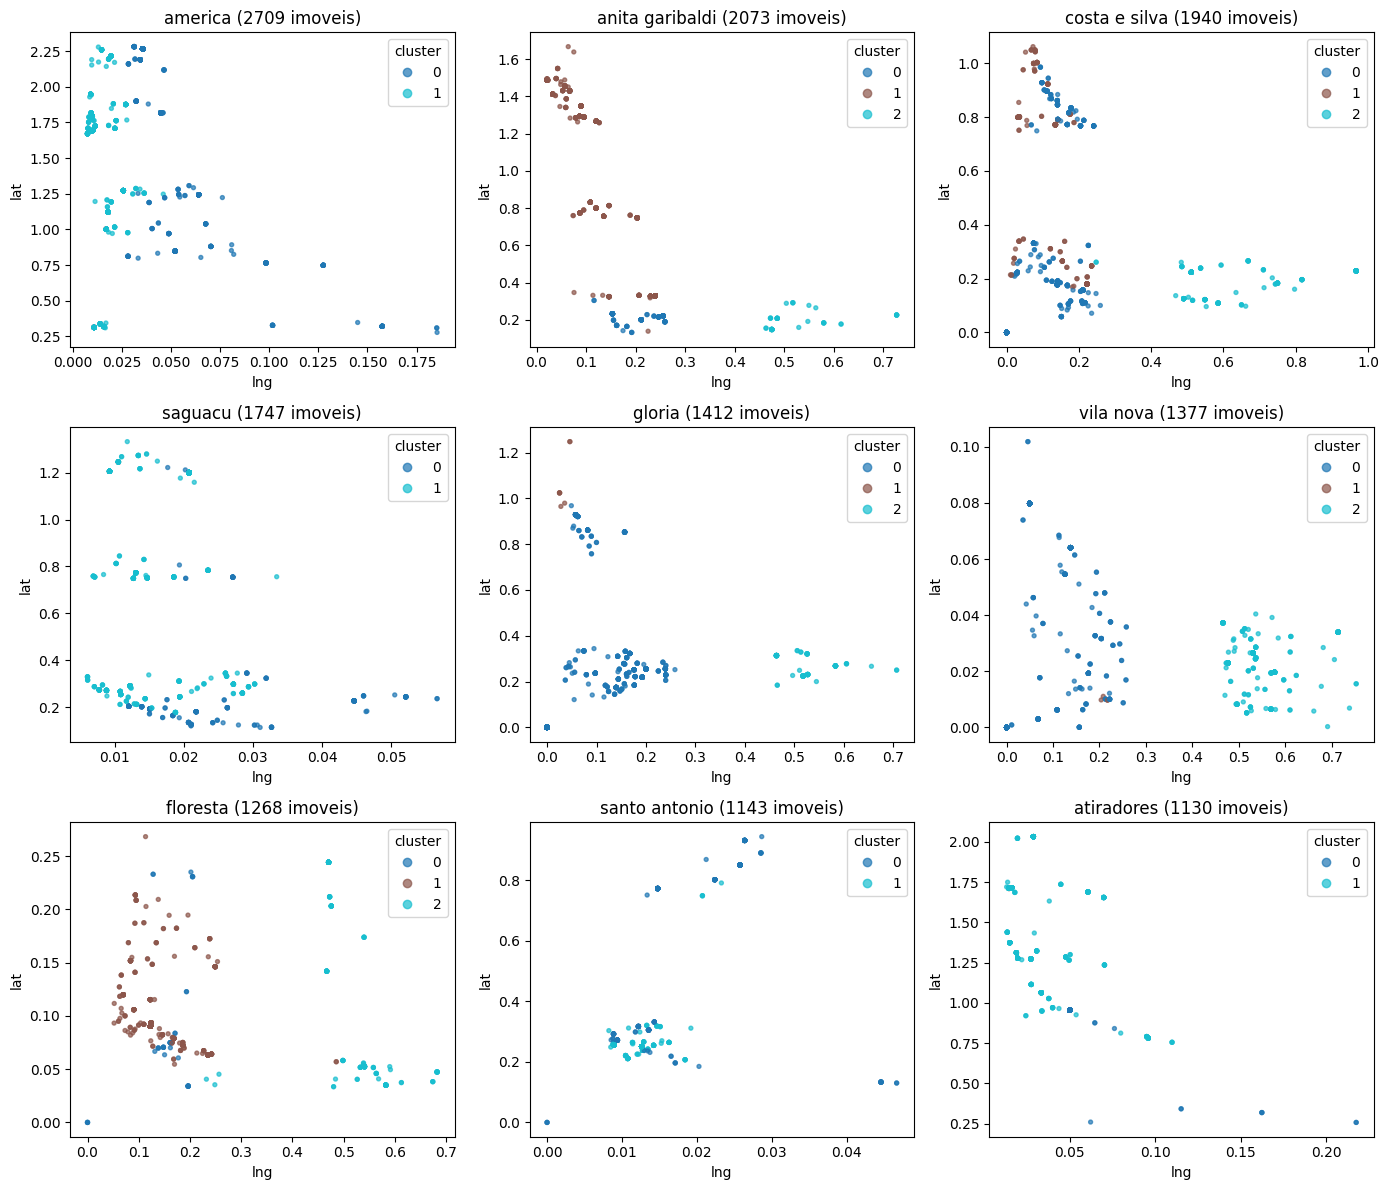

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.concat([train, test], ignore_index=True)

n_bairros = df["bairro"].nunique()
n_clusters = df["bairro_cluster"].nunique()
print(f"{n_bairros} bairros | {n_clusters} clusters no total")
print(df.groupby("bairro")["bairro_cluster"].nunique().describe())

# ── Grid de subplots: um por bairro (top N maiores) ──
top_bairros = df["bairro"].value_counts().head(9).index
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for ax, bairro in zip(axes.flat, top_bairros):
    sub = df[df["bairro"] == bairro]
    cores = sub["bairro_cluster"]
    scatter = ax.scatter(sub["score_escola_publica"], sub["score_hospitais"], c=cores, cmap="tab10",
                         s=8, alpha=0.7)
    ax.set_title(f"{bairro} ({len(sub)} imoveis)")
    ax.set_xlabel("lng")
    ax.set_ylabel("lat")
    ax.legend(*scatter.legend_elements(), title="cluster")

plt.tight_layout()
#plt.savefig("clusters_bairro_grid.png", dpi=150)
plt.show()

In [16]:
df_apartamento = df[df["tipo_imovel"] == "apartamento"]

In [17]:
df_apartamento.groupby(["bairro", "bairro_cluster"])['preco_por_m2'].agg(['mean','median', 'count']).head(60)

mean        median  count
bairro              bairro_cluster                                   
adhemar garcia      0                3658.727291   3522.359069     10
                    2                4632.021857   4431.891026     30
america             0               10387.974834  10515.361446   1327
                    1                9905.098085   9819.322056    534
anita garibaldi     0                8407.756880   8474.746032     87
                    1                9071.499242   8982.025682   1400
                    2                7709.992304   7598.750000     20
atiradores          0               10454.628900  10227.272727    631
                    1                9725.974515   9375.000000    304
aventureiro         0                5292.274116   5323.717949     18
                    1                5458.611703   5390.625000     37
                    2                5407.358775   5425.531915     87
boa vista           0                5361.092577   5085.293264     34
                    1                4867.373464   4650.000000     11
                    2                4805.787233   4705.882353      5
boehmerwald         0                4849.583239   4907.575758     30
                    2                3514.452667   3673.469388      9
bom retiro          0                7418.481526   7160.493827    271
                    1                6788.277874   6439.671815     72
                    2                6859.602164   6596.491228      9
bucarein            0                7259.261797   7250.000000     11
                    1                7326.567082   6863.485222    226
centro              1               10006.432051   9862.068966    667
comasa              0                5209.466496   5909.090909     23
                    2                4728.090892   4409.836066     13
costa e silva       0                6971.736320   6969.696970    849
                    1                6607.309267   6699.810606    126
                    2                6490.273923   6471.586575     88
distrito industrial 0                5991.254146   6137.593220     20
                    1                8627.450980   8627.450980      2
espinheiros         0                6677.657705   7064.705882     13
                    2                7114.845232   7127.000000      9
fatima              0                5966.089410   5877.777778     40
                    2                7596.843434   7596.843434      2
floresta            0                5565.924508   5530.586767      8
                    1                6235.471742   6185.238095    278
                    2                6080.617668   6259.129902     84
gloria              0                8526.710700   8223.249041    438
                    1               12588.717371  11785.714286      5
                    2                7387.647361   8018.557692     31
guanabara           0                6029.261103   6062.500000     15
                    1                6136.220666   6667.271408      8
                    2                5944.048769   5922.146636     82
iririu              0                5962.684670   5778.221899    176
                    1                5838.437742   5699.117276     12
                    2                5687.680732   5721.390169     28
itaum               0                5805.052361   5348.790323      6
                    1                6297.813145   6370.903147    110
itinga              0                5610.972569   5610.972569      1
                    2                4509.803922   4509.803922      1
jardim iririu       0                5217.942177   5392.307692      8
                    1                4086.525064   5111.111111      3
                    2                4898.527976   4815.188172     38
jardim paraiso      0                3769.390409   3308.973173      6
                    1                2722.727273   2722.727273      1
                    2                2301.510311   237

In [34]:
df.groupby(["bairro", "bairro_cluster"])['preco_por_m2'].agg(['mean','median', 'count']).head(40)

mean       median  count
bairro              bairro_cluster                                 
adhemar garcia      0               4607.110477  4658.057913    140
                    1               3276.740035  2770.208333     20
america             1               9504.061603  9554.150442   2187
                    2               9108.909515  8832.460733    519
anita garibaldi     0               7459.933152  6810.688557     46
                    1               8059.328566  8326.330532   1430
                    2               8044.035518  8175.841270    597
area rural          1               3943.034529  4593.750000     11
atiradores          1               9672.058247  9743.236748    784
                    2               9062.707908  8858.951175    346
aventureiro         0               5093.248836  5370.879121    336
                    1               4640.499172  4932.834620    142
                    2               5713.869878  6176.504630     24
boa vista           0               4262.088634  4795.918367     37
                    1               5001.376612  5064.610390    374
                    2               5313.337592  5252.696823     62
boehmerwald         0               3307.480260  3506.807202     46
                    1               3692.957523  3750.000000    211
bom retiro          0               5854.859868  5714.285714     77
                    1               8471.553343  6116.725806    913
                    2               6622.049093  6901.918977     32
bucarein            1               6523.009604  6541.958042    272
                    2               6046.457987  6060.777710    136
centro              1               2084.282291  1320.384615      4
                    2               8984.843348  8703.703704    881
comasa              0               4785.646163  4860.224521     66
                    1               4678.403572  4871.794872    141
costa e silva       0               5790.972189  5972.222222    179
                    1               6242.840152  6231.941598   1576
                    2               6111.978449  6082.802548    185
distrito industrial 0                500.000000   500.000000      3
                    1               3553.531655  1791.699605     94
                    2                700.210063   700.210063      1
espinheiros         0               3957.081038  4798.666667     51
                    1               5296.156179  5474.137931    109
fatima              0               3866.727803  3601.694915     23
                    1               4508.171553  4677.083333    132
floresta            0               5431.179880  5462.962963    131
                    1               4255.439540  4530.303030     69
                    2               4899.755627  5156.250000   1068

In [ ]:
import folium
df_apartamento = df.dropna(subset="lat")
df_apartamento = df.dropna(subset="lat")

mapa = folium.Map(location=[df["lat"].mean(), df["lng"].mean()], zoom_start=12)

cores = ["red", "blue", "green", "purple", "orange"]

for _, row in df_apartamento.iterrows():
    if pd.isna(row.get("bairro_cluster")):
        continue
    cor = cores[int(row["bairro_cluster"]) % len(cores)]
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=3,
        color=cor,
        fill=True,
        popup=f"{row['bairro']} — cluster {int(row['bairro_cluster'])}",
    ).add_to(mapa)

mapa.show_in_browser()
#mapa

Your map should have been opened in your browser automatically.
Press ctrl+c to return.
